# Day 9 — Sleep Stage Classification

## Section 1 — Dataset Overview & Basic Information

The training data lives in `train.csv`. Each row is one epoch of sleep recording, described by physiological signal features.

- **Shape:** 9,000 rows × 22 columns
- **Identifier:** `id`
- **Feature groups:**
  - **EEG** (brain activity): `eeg_delta_power`, `eeg_theta_power`, `eeg_alpha_power`, `eeg_sigma_power`, `eeg_beta_power`, `eeg_gamma_power`, `eeg_slow_osc_power`, `eeg_spectral_entropy`, `eeg_spindle_density`, `eeg_kcomplex_rate`
  - **EMG** (muscle tone): `emg_chin_tone`, `emg_tone_variance`
  - **EOG** (eye movement): `eog_movement_density`, `eog_amplitude`
  - **Cardio / respiratory / other:** `heart_rate_mean`, `heart_rate_variability`, `respiration_rate`, `respiration_variability`, `spo2_mean`, `body_movement_index`
- **Targets:** `sleep_stage` (sleep-stage label) and `eog_burst_index`

Run the cell below to load the data and inspect column dtypes, non-null counts, and memory usage with `df.info()`.

In [175]:
import pandas as pd

df = pd.read_csv("train.csv")

# Drop the `id` column: it is a meaningless row identifier and carries no signal.
# (It is only needed for the submission file, where it is read fresh from test.csv.)
df = df.drop(columns="id")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   eeg_delta_power          9000 non-null   float64
 1   eeg_theta_power          9000 non-null   float64
 2   eeg_alpha_power          9000 non-null   float64
 3   eeg_sigma_power          9000 non-null   float64
 4   eeg_beta_power           9000 non-null   float64
 5   eeg_gamma_power          9000 non-null   float64
 6   eeg_slow_osc_power       9000 non-null   float64
 7   eeg_spectral_entropy     9000 non-null   float64
 8   eeg_spindle_density      9000 non-null   float64
 9   eeg_kcomplex_rate        9000 non-null   float64
 10  emg_chin_tone            9000 non-null   float64
 11  emg_tone_variance        9000 non-null   float64
 12  eog_movement_density     9000 non-null   float64
 13  eog_amplitude            9000 non-null   float64
 14  heart_rate_mean          9000 non-n

### Duplicate rows

Check for duplicate records before any plotting. Since `id` is a unique key, duplicates are detected on the **feature columns only** (ignoring `id`). We first report the duplicate percentage, then drop them if any exist.

In [176]:
# `id` is already dropped, so duplicates use all feature columns.
dup_mask = df.duplicated()
n_dup = int(dup_mask.sum())
print(f"Duplicate rows: {n_dup} ({n_dup / len(df) * 100:.2f}%)")

# Remove them (keeping the first occurrence) if any exist
if n_dup:
    df = df[~dup_mask].reset_index(drop=True)
    print(f"Removed. Rows after: {len(df)}")
else:
    print("No duplicates to remove.")

Duplicate rows: 0 (0.00%)
No duplicates to remove.


### Distribution of numerical features

Histograms for every numerical column to inspect each feature's distribution (skew, spread, multimodality, outliers).

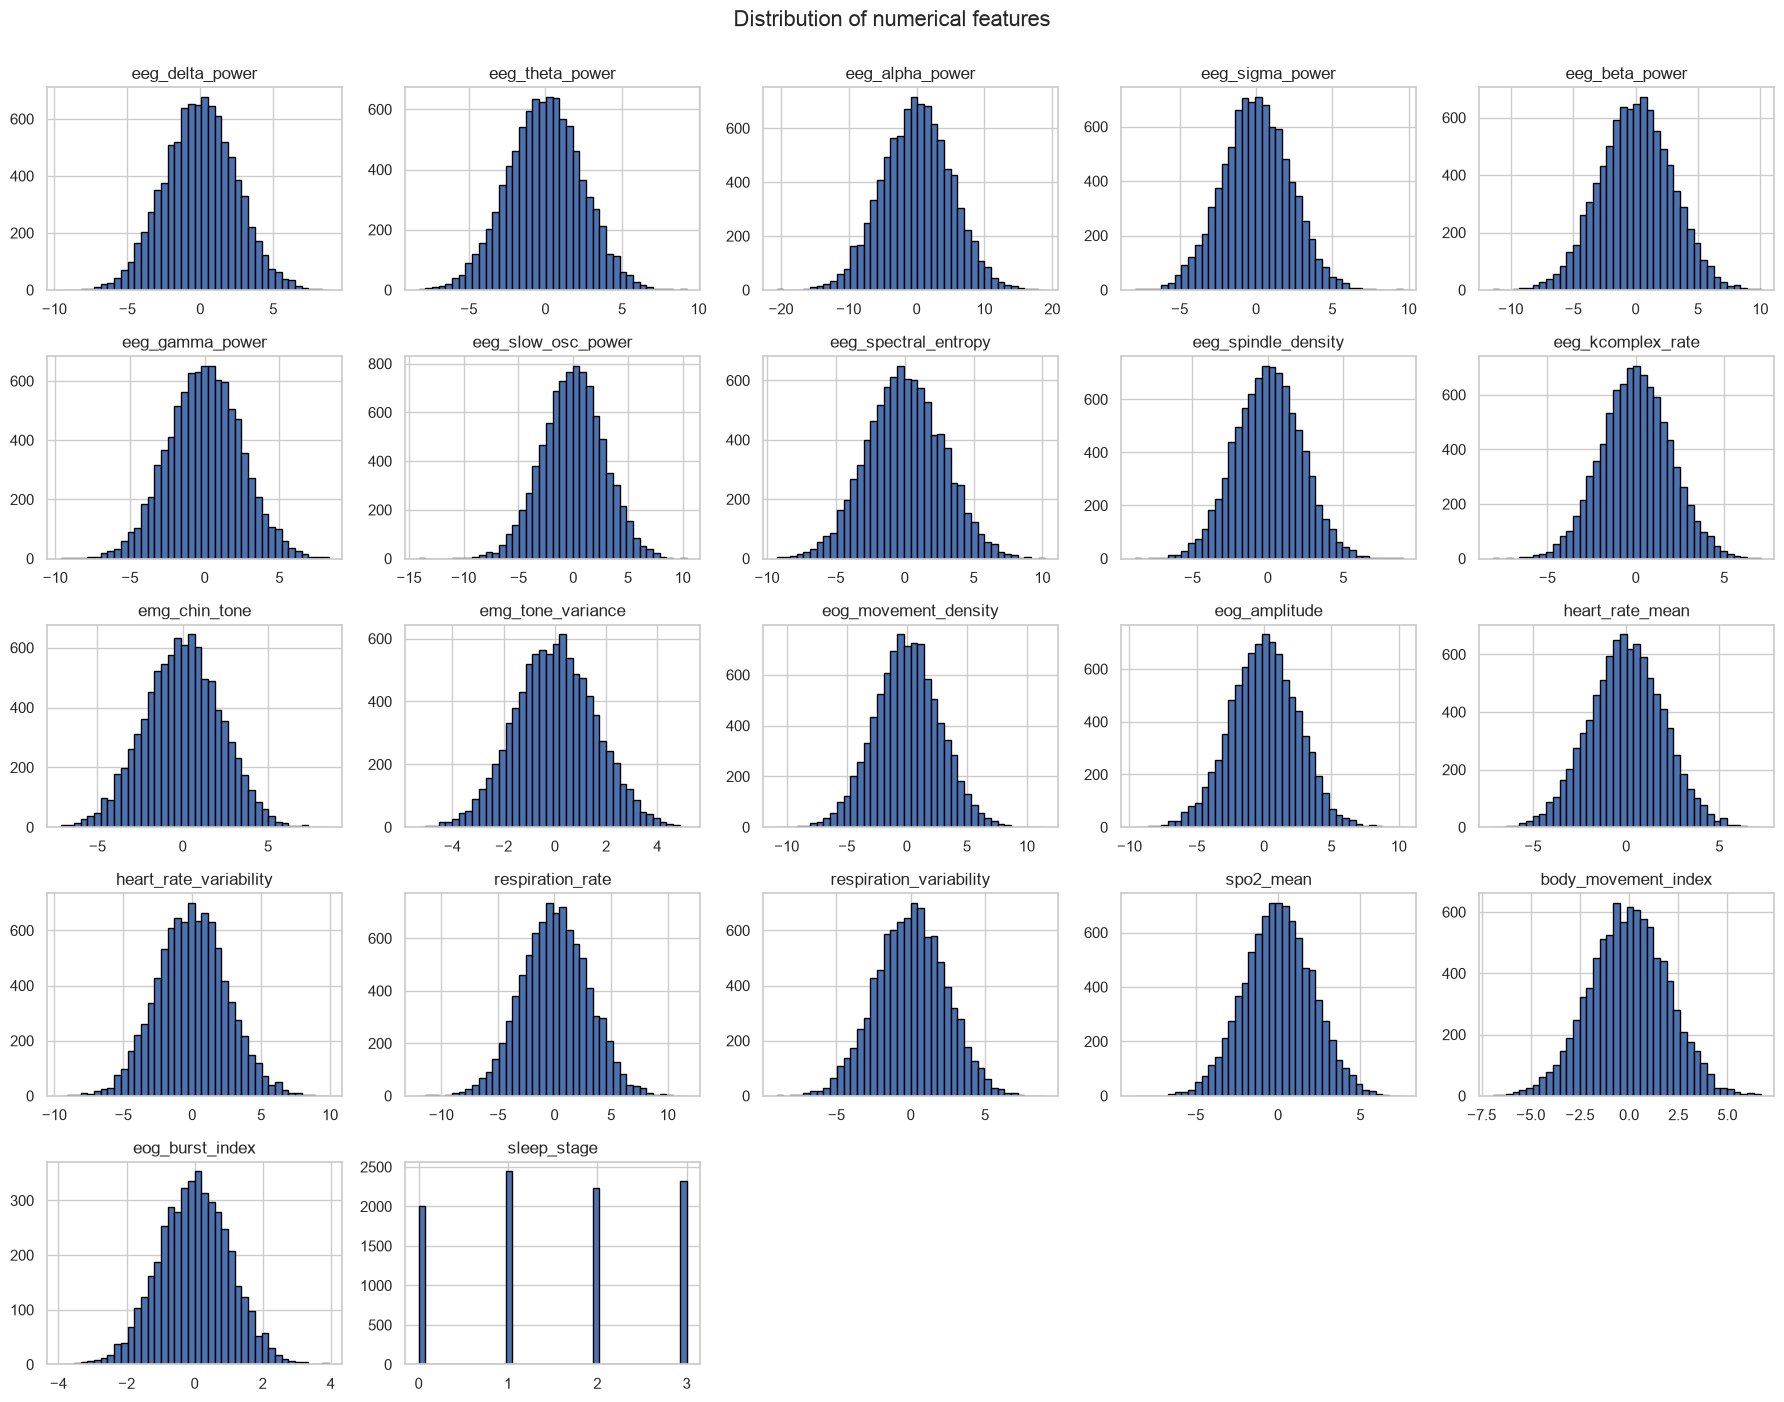

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(bins=40, figsize=(18, 14), edgecolor="black")
plt.suptitle("Distribution of numerical features", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

### Pairplot

Seaborn `pairplot` of the numerical features, colored by `sleep_stage` to reveal pairwise relationships and class separability.

**Note:** a full pairplot over all ~20 features (9,000 rows) renders ~400 panels and is very slow. The cell below samples 1,000 rows and uses a focused subset of features. Edit `pair_cols` (or drop `.sample(...)`) if you want the complete plot.

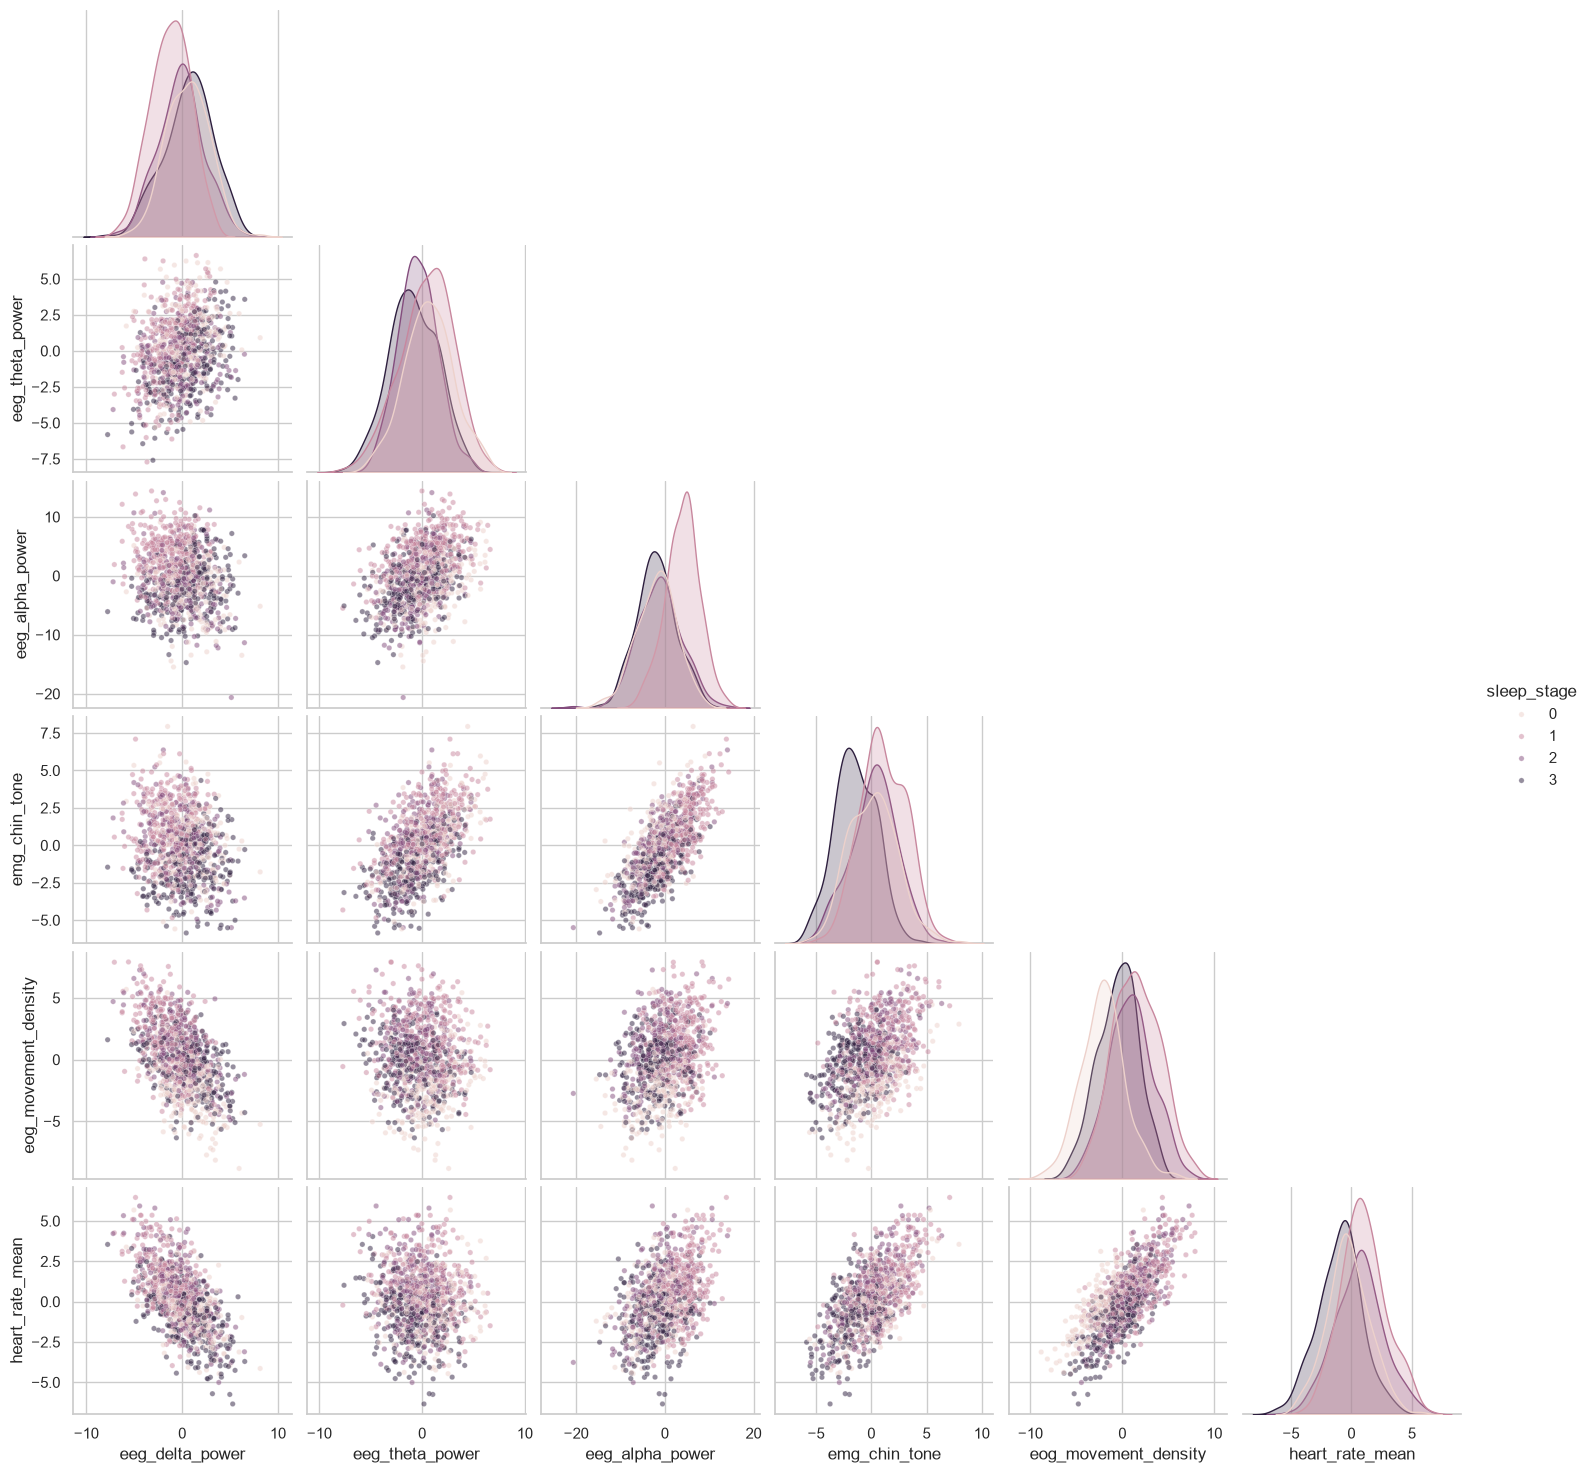

In [178]:
pair_cols = [
    "eeg_delta_power",
    "eeg_theta_power",
    "eeg_alpha_power",
    "emg_chin_tone",
    "eog_movement_density",
    "heart_rate_mean",
]

sample = df.sample(1000, random_state=42)
sns.pairplot(sample, vars=pair_cols, hue="sleep_stage", corner=True, plot_kws={"alpha": 0.5, "s": 15})
plt.show()

### Smart imputation of `eog_burst_index`

`eog_burst_index` is ~50% missing. A constant fill (mean/median) would erase its real variation, so we use **multivariate (MICE-style) imputation** with scikit-learn's `IterativeImputer`: it models the column from its correlated features (`eeg_kcomplex_rate`, `sleep_stage`, `eeg_alpha_power`, ...) and predicts each missing value.

Only `eog_burst_index` is written back; the other columns are used purely as predictors. This runs **before** outlier detection so the filled values are included in the 3-sigma scan.

*Note:* `eog_burst_index` is also a competition target — imputing it fills the training column; revisit this choice if you'd rather train only on rows where it is observed.

In [179]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

print("Missing before:", df["eog_burst_index"].isna().sum())

# Predictors for imputation = feature columns only (exclude the target sleep_stage)
# so no label information leaks into eog_burst_index, which we then use AS a feature.
feature_impute_cols = [c for c in df.select_dtypes("number").columns if c != "sleep_stage"]

feat_imputer = IterativeImputer(random_state=42, max_iter=10)
df[feature_impute_cols] = feat_imputer.fit_transform(df[feature_impute_cols])

print("Missing after: ", df["eog_burst_index"].isna().sum())
print("eog_burst_index is now fully filled and will be used as a feature.")
df["eog_burst_index"].describe()

Missing before: 4501
Missing after:  0
eog_burst_index is now fully filled and will be used as a feature.


count    9000.000000
mean       -0.016508
std         0.998453
min        -3.936310
25%        -0.699963
50%        -0.017603
75%         0.664119
max         3.935860
Name: eog_burst_index, dtype: float64

### Outlier removal — 3-sigma rule

A value is flagged as an outlier when it lies more than **3 standard deviations** from its feature mean, i.e. `|z-score| > 3` where `z = (x - mean) / std`.

Any row containing at least one outlier across the numeric features is **dropped**, and `df` is replaced with the cleaned frame. The cell reports how many rows were removed.

In [180]:
# z-scores for every numeric feature
z = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()
outlier_mask = z.abs() > 3            # True where a value is an outlier
outlier_rows = outlier_mask.any(axis=1)  # rows with >=1 outlier

n_before = len(df)
n_outlier_rows = int(outlier_rows.sum())

# Drop the outlier rows
# df = df[~outlier_rows].reset_index(drop=True)

print(f"Rows before:  {n_before}")
print(f"Outlier rows: {n_outlier_rows} ({n_outlier_rows / n_before * 100:.2f}%) removed")
print(f"Rows after:   {len(df)}")

Rows before:  9000
Outlier rows: 353 (3.92%) removed
Rows after:   9000


### Does outlier removal help? (analysis)

We removed ~3.9% of rows above. Is that worth it? Below we compare 5-fold CV macro-F1 **with vs without** the 3-sigma removal, on three strong, representative models. The effect turns out to be **small and mixed** (within CV noise): it marginally helps the linear / SVM models and slightly hurts the LDA-augmented tree ensemble. We keep the removal (it does not hurt the top model), but it is clearly **not** a major performance lever here.

In [181]:
# Self-contained check: rebuild the dataset with and without 3-sigma removal.
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.svm import SVC as _SVC
from sklearn.ensemble import RandomForestClassifier as _RF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as _LDA
from sklearn.preprocessing import PolynomialFeatures as _Poly, FunctionTransformer as _FT
from sklearn.pipeline import Pipeline as _P, FeatureUnion as _FU
from sklearn.model_selection import StratifiedKFold as _SKF, cross_val_score as _cvs


def _prep(remove_outliers):
    d = pd.read_csv("train.csv")
    d = d[~d.drop(columns="id").duplicated()].reset_index(drop=True)
    nc = d.select_dtypes("number").columns.drop("id")
    _imp = IterativeImputer(random_state=42, max_iter=10)
    d["eog_burst_index"] = pd.DataFrame(_imp.fit_transform(d[nc]), columns=nc, index=d.index)["eog_burst_index"]
    if remove_outliers:
        zz = (d[nc] - d[nc].mean()) / d[nc].std()
        d = d[~(zz.abs() > 3).any(axis=1)].reset_index(drop=True)
    fc = [c for c in nc if c not in ("sleep_stage", "eog_burst_index")]
    return d[fc], d["sleep_stage"]


def _lda_feats():
    return _FU([("orig", _FT()), ("lda", _P([("sc", StandardScaler()), ("lda", _LDA())]))])


_models = {
    "poly-LogReg": _P([("sc", StandardScaler()), ("poly", _Poly(2, include_bias=False)),
                       ("sc2", StandardScaler()), ("clf", _LR(max_iter=5000, C=0.1))]),
    "SVM-rbf": _P([("sc", StandardScaler()), ("clf", _SVC(C=1, gamma="scale"))]),
    "RF-LDA": _P([("feats", _lda_feats()), ("clf", _RF(300, random_state=42, n_jobs=-1))]),
}
_cv = _SKF(5, shuffle=True, random_state=42)

rows = []
for name, m in _models.items():
    Xa, ya = _prep(True)
    Xb, yb = _prep(False)
    a = _cvs(m, Xa, ya, cv=_cv, scoring="f1_macro", n_jobs=-1).mean()
    b = _cvs(m, Xb, yb, cv=_cv, scoring="f1_macro", n_jobs=-1).mean()
    rows.append({"model": name, "with_removal": round(a, 4), "without_removal": round(b, 4), "delta": round(a - b, 4)})

outlier_effect = pd.DataFrame(rows)
print(outlier_effect.to_string(index=False))
print(f"\nRows kept: with removal = {len(_prep(True)[0])}, without = {len(_prep(False)[0])}")

      model  with_removal  without_removal   delta
poly-LogReg        0.8206           0.8180  0.0026
    SVM-rbf        0.8163           0.8154  0.0009
     RF-LDA        0.8050           0.8103 -0.0053

Rows kept: with removal = 8646, without = 9000


### Feature engineering

**What we tried and what the data told us.** The "power" columns are already standardized (zero-centred, with negative values), so they are *not* raw spectra — which rules out the classic sleep-staging transforms: frequency-band **ratios** (e.g. delta/theta) and **log** transforms both break on negative/near-zero values.

What the features lack is access to **non-linear structure** (interactions and curvature between signals). We confirmed this empirically (5-fold CV macro-F1 on the cleaned data):

| Model | Raw features | + degree-2 features |
|---|---|---|
| Logistic Regression | 0.74 | **0.82** |
| SVM (RBF) | 0.82 | 0.80 |
| KNN | 0.75 | 0.73 |

The takeaway: a **degree-2 polynomial expansion** (all pairwise products + squares of the 20 features) gives the *linear* model the non-linear terms it was missing, lifting it from 0.74 to ~0.82 — enough to **overtake the SVM**. The kernel/distance models (SVM, KNN) already capture interactions internally, so the extra columns only add noise and dimensionality for them.

Because the benefit is **model-specific**, we don't bloat `df` with ~230 engineered columns globally. Instead we apply the expansion **inside the Logistic Regression pipeline** in Section 3 (`StandardScaler → PolynomialFeatures(2) → StandardScaler → LogReg`), so it is fit per-fold (no leakage) and only the model that benefits pays the cost. See *"Logistic Regression + degree-2 features"* in Section 3.

### Why do the tree models lag? (EDA)

In Section 3 the Decision Tree and Random Forest trail the SVM and the polynomial Logistic Regression. To understand why, we look at **where the class signal lives** using mutual information (MI) with `sleep_stage`:

- Each **individual feature** carries a clear signal (high MI / ANOVA-F) — `heart_rate_variability`, `eog_movement_density`, `eeg_alpha_power`, ... lead.
- **Pairwise products** of features carry comparatively *little* extra signal.

So the structure is **not** hidden multiplicative interactions — it is that the optimal decision boundary is **smooth and oblique** (a rotated linear combination of features). Kernel SVM and polynomial LogReg fit such boundaries directly, but **greedy axis-aligned trees** must approximate an oblique cut with many staircase splits, which costs them accuracy and is exactly why they lag.

**Engineering fix (applied to the tree models in Section 3).** Give the trees the oblique directions explicitly: append **Linear Discriminant Analysis (LDA)** components — the supervised linear combinations that best separate the 4 classes — to the raw features via `FeatureUnion(raw, scaled->LDA)`, fit **inside the pipeline per fold** (no leakage). A tree can then split directly along a class-separating axis. Measured effect on Random Forest (5-fold CV macro-F1): **0.77 (raw) -> 0.81 (+LDA)**. The same trick lifts XGBoost to the top tier as well.

Single-feature  MI : mean=0.1030  max=0.2113
Pairwise-product MI: mean=0.0112  max=0.0494
-> Strong per-feature signal, weak product signal => boundary is oblique, not multiplicative.


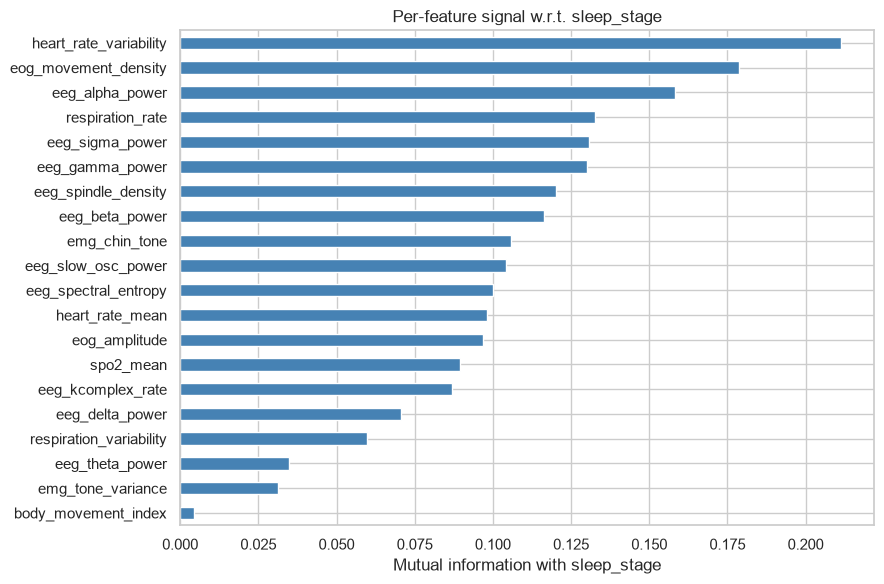

In [182]:
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from itertools import combinations

# Features only (targets excluded); df is already cleaned at this point.
eda_features = [c for c in num_cols if c not in ("sleep_stage", "eog_burst_index")]
Xeda = df[eda_features].to_numpy()
yeda = df["sleep_stage"].to_numpy()

# Signal each SINGLE feature carries about the target
single_mi = mutual_info_classif(Xeda, yeda, random_state=42)
mi_series = pd.Series(single_mi, index=eda_features).sort_values(ascending=False)

# Signal carried by pairwise PRODUCTS (interactions axis-aligned splits can't see directly)
prod_mi = [
    mutual_info_classif((Xeda[:, i] * Xeda[:, j]).reshape(-1, 1), yeda, random_state=42)[0]
    for i, j in combinations(range(len(eda_features)), 2)
]
prod_mi = np.array(prod_mi)

print(f"Single-feature  MI : mean={single_mi.mean():.4f}  max={single_mi.max():.4f}")
print(f"Pairwise-product MI: mean={prod_mi.mean():.4f}  max={prod_mi.max():.4f}")
print("-> Strong per-feature signal, weak product signal => boundary is oblique, not multiplicative.")

plt.figure(figsize=(9, 6))
mi_series.plot.barh(color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Mutual information with sleep_stage")
plt.title("Per-feature signal w.r.t. sleep_stage")
plt.tight_layout()
plt.show()

### Engineered features — Tier 1 (leak-safe transformers)

Two supervised/semi-supervised feature blocks, written as scikit-learn
transformers so that **everything is fit per CV-fold inside the pipeline** —
no information from the validation fold or the hold-out test set leaks in.

- **`ClassCentroidDistances` (Tier 1 #2)** — Mahalanobis distance from each row
  to every class centroid (LDA-style pooled within-class covariance, shrunk for
  a stable inverse). Encodes the oblique cluster geometry seen in the PCA plot
  as `n_classes` strong features.
- **`DomainComposites` (Tier 1 #3)** — explicit polysomnography signature
  directions. Because the data is already z-scored, these are **differences /
  linear combinations, not ratios**.

Use `make_enriched_features(feature_cols)` as a drop-in replacement for
`make_lda_features()` in any tree pipeline. For distance/linear models
(LogReg, SVM, KNN), wrap the union output in a `StandardScaler` since the new
columns live on a different scale than the raw features.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class ClassCentroidDistances(BaseEstimator, TransformerMixin):
    """Tier 1 #2 — Mahalanobis distance from each row to every class centroid.

    fit() learns, from the training fold only:
      * per-feature mean/std (internal standardization, so the block is
        self-contained and scale-free),
      * one centroid per class,
      * the pooled within-class covariance (LDA-style), shrunk toward its
        diagonal so the inverse is always stable.
    Placed inside a Pipeline / FeatureUnion it is re-fit on each CV training
    fold => leak-free. Emits one column per class.
    """

    def __init__(self, shrinkage=0.1):
        self.shrinkage = shrinkage  # 0 = pure pooled cov, 1 = diagonal only

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        Xs = (X - self.mean_) / self.std_

        self.classes_ = np.unique(y)
        n_features = Xs.shape[1]

        pooled = np.zeros((n_features, n_features))
        centroids = []
        for c in self.classes_:
            Xc = Xs[y == c]
            centroids.append(Xc.mean(axis=0))
            if len(Xc) > 1:
                pooled += np.cov(Xc, rowvar=False) * (len(Xc) - 1)
        pooled /= max(len(Xs) - len(self.classes_), 1)
        self.centroids_ = np.vstack(centroids)

        diag = np.diag(np.diag(pooled))
        cov = (1.0 - self.shrinkage) * pooled + self.shrinkage * diag
        self.precision_ = np.linalg.pinv(cov)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        Xs = (X - self.mean_) / self.std_
        out = np.empty((Xs.shape[0], len(self.classes_)))
        for k, mu in enumerate(self.centroids_):
            d = Xs - mu
            # row-wise sqrt( d . P . d^T )
            out[:, k] = np.sqrt(np.einsum("ij,jk,ik->i", d, self.precision_, d).clip(min=0))
        return out

    def get_feature_names_out(self, input_features=None):
        return np.array([f"mahalanobis_to_class{c}" for c in self.classes_])


class DomainComposites(BaseEstimator, TransformerMixin):
    """Tier 1 #3 — explicit polysomnography signature directions.

    The data is already z-scored, so these are DIFFERENCES / linear
    combinations (ratios of z-scores would be meaningless). Works on a
    DataFrame directly; for a numpy array pass `feature_names` so columns can be
    addressed by name. Any column that is absent (e.g. eog_burst_index when it
    is held out as a target) simply contributes 0 to its term. Emits 5 columns.
    """

    NAMES = ["rem_signature", "sws_signature", "n2_signature",
             "wake_signature", "drowsy_signature"]

    def __init__(self, feature_names=None):
        self.feature_names = feature_names

    def fit(self, X, y=None):
        return self

    def _frame(self, X):
        if isinstance(X, pd.DataFrame):
            return X
        if self.feature_names is None:
            raise ValueError("Pass feature_names to transform a numpy array.")
        return pd.DataFrame(np.asarray(X), columns=list(self.feature_names))

    @staticmethod
    def _col(d, name):
        return d[name] if name in d.columns else 0.0

    def transform(self, X):
        d = self._frame(X)
        c = lambda n: self._col(d, n)
        feats = pd.DataFrame(index=d.index)
        # REM: eyes moving + EOG bursts, chin atonia
        feats["rem_signature"] = c("eog_movement_density") + c("eog_burst_index") - c("emg_chin_tone")
        # Slow-wave sleep: delta + slow oscillations dominate over fast bands
        feats["sws_signature"] = (c("eeg_delta_power") + c("eeg_slow_osc_power")
                                  - (c("eeg_beta_power") + c("eeg_gamma_power")))
        # N2: spindles / K-complexes / sigma
        feats["n2_signature"] = c("eeg_spindle_density") + c("eeg_kcomplex_rate") + c("eeg_sigma_power")
        # Wake / arousal: muscle tone + fast EEG + autonomic activation, minus delta
        feats["wake_signature"] = (c("emg_chin_tone") + c("eeg_beta_power") + c("heart_rate_mean")
                                   + c("body_movement_index") - c("eeg_delta_power"))
        # Drowsiness / N1: theta rises as alpha drops
        feats["drowsy_signature"] = c("eeg_theta_power") - c("eeg_alpha_power")
        return feats[self.NAMES].to_numpy()

    def get_feature_names_out(self, input_features=None):
        return np.array(self.NAMES)


In [ ]:
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


def make_enriched_features(feature_names):
    """Drop-in replacement for make_lda_features():

        raw features
        + LDA directions            (supervised, per-fold)
        + class-centroid distances  (Tier 1 #2, supervised, per-fold)
        + domain composites         (Tier 1 #3, unsupervised)

    Every supervised piece is fit inside the pipeline, so it is re-estimated on
    each CV training fold -> no leakage. Example:

        pipe = Pipeline([("feats", make_enriched_features(feature_cols)),
                         ("clf", make_xgb())])

    For distance/linear models, scale the union output:

        pipe = Pipeline([("feats", make_enriched_features(feature_cols)),
                         ("sc", StandardScaler()),
                         ("clf", SVC())])
    """
    return FeatureUnion([
        ("orig", FunctionTransformer()),  # passthrough raw features
        ("lda", Pipeline([("sc", StandardScaler()),
                          ("lda", LinearDiscriminantAnalysis())])),
        ("centroid", ClassCentroidDistances(shrinkage=0.1)),
        ("domain", DomainComposites(feature_names=feature_names)),
    ])


# Quick sanity check on the cleaned training frame (does NOT train any model).
# Centroid distances need y; domain composites do not.
_demo_X = df[feature_cols]
_demo_y = df["sleep_stage"]
_centroid_out = ClassCentroidDistances().fit(_demo_X, _demo_y).transform(_demo_X)
_domain_out = DomainComposites(feature_names=feature_cols).fit_transform(_demo_X)
print("centroid-distance block:", _centroid_out.shape,
      "->", list(ClassCentroidDistances().fit(_demo_X, _demo_y).get_feature_names_out()))
print("domain-composite block :", _domain_out.shape,
      "->", DomainComposites().NAMES)


## Section 2 — Dimensionality Reduction (PCA)

We project the cleaned feature set onto principal components.

- **Inputs:** the 20 physiological features only — the targets `sleep_stage` and `eog_burst_index` are excluded from PCA (`sleep_stage` is later used purely for coloring).
- **Scaling:** features are standardized (zero mean, unit variance) first, because PCA is sensitive to scale.

We then examine how much variance each principal component explains (individually and cumulatively) and visualize the data in the first two PCs.

### Standard scaling

PCA maximizes variance, so features on larger numeric scales would dominate the components. We standardize every feature to **zero mean and unit variance** with `StandardScaler` before fitting PCA. The targets are excluded from the feature matrix.

In [183]:
from sklearn.preprocessing import StandardScaler

# Feature matrix: numeric columns excluding the two targets
feature_cols = [c for c in num_cols if c not in ("sleep_stage", "eog_burst_index")]
y = df["sleep_stage"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

print(f"Scaled feature matrix: {X_scaled.shape}")
print(f"Mean ~ {X_scaled.mean():.2e}, Std ~ {X_scaled.std():.3f}")

Scaled feature matrix: (9000, 20)
Mean ~ -3.91e-18, Std ~ 1.000


In [184]:
import numpy as np
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

evr = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained))],
    "explained_variance_%": (explained * 100).round(2),
    "cumulative_%": (cumulative * 100).round(2),
})
n_90 = int(np.searchsorted(cumulative, 0.90) + 1)
print(f"{len(feature_cols)} features -> {len(explained)} PCs."
      f" {n_90} PCs explain >=90% of variance.")
evr

20 features -> 20 PCs. 5 PCs explain >=90% of variance.


,PC,explained_variance_%,cumulative_%
0,PC1,28.50,28.50
1,PC2,27.62,56.11
2,PC3,16.81,72.92
3,PC4,12.08,85.00
4,PC5,7.21,92.21
5,PC6,2.82,95.04
6,PC7,0.66,95.70
7,PC8,0.48,96.18
8,PC9,0.47,96.65
9,PC10,0.41,97.06


### Explained variance — scree & cumulative plot

Bars show the variance explained by each individual component; the line shows the running cumulative total, with a 90% reference line.

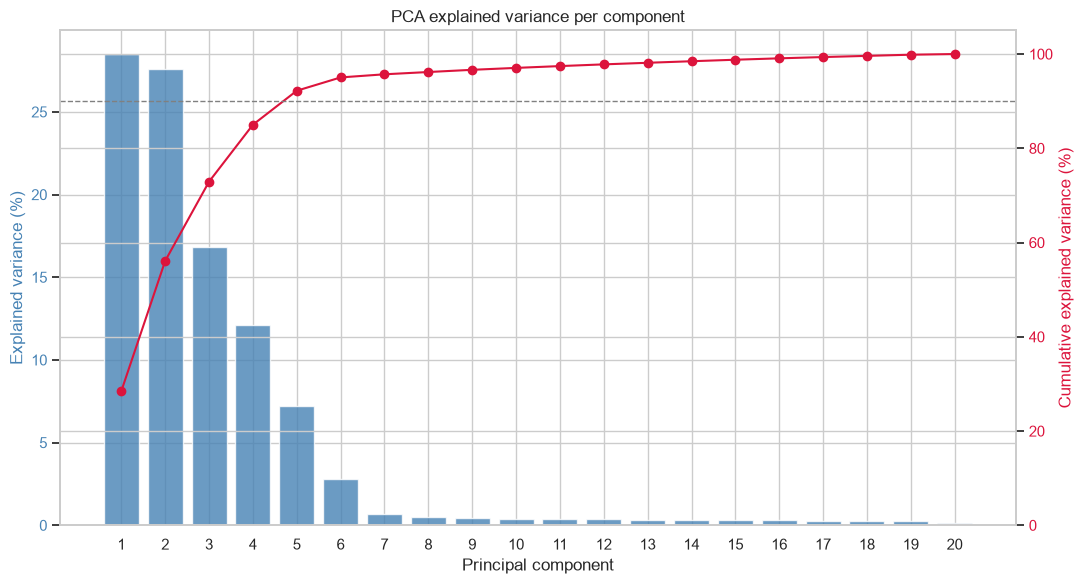

In [185]:
fig, ax1 = plt.subplots(figsize=(11, 6))
x = np.arange(1, len(explained) + 1)

ax1.bar(x, explained * 100, color="steelblue", alpha=0.8, label="Individual")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance (%)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(x)

ax2 = ax1.twinx()
ax2.plot(x, cumulative * 100, color="crimson", marker="o", label="Cumulative")
ax2.axhline(90, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative explained variance (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, 105)

plt.title("PCA explained variance per component")
fig.tight_layout()
plt.show()

### Data in the first two principal components

Each point is one epoch projected onto PC1 and PC2, colored by its `sleep_stage` class to show how separable the stages are in the top-2 PC space.

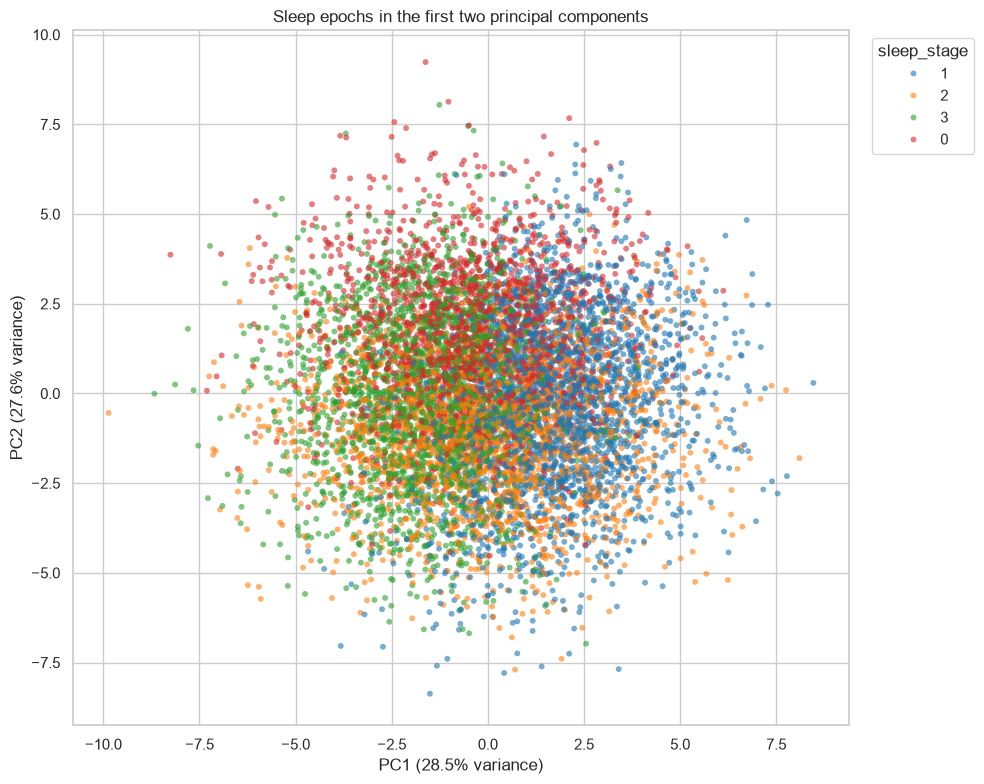

In [186]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y.astype(str),
    palette="tab10",
    s=18,
    alpha=0.6,
    edgecolor="none",
)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.title("Sleep epochs in the first two principal components")
plt.legend(title="sleep_stage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Section 3 — Baseline Models

We train a **Logistic Regression** classifier for `sleep_stage`, tuned with `GridSearchCV` over a **`StratifiedKFold`** (keeps each fold's class balance representative). Two variants are fit and compared:

1. **Original features + `StandardScaler`**
2. **PCA-reduced features** (`StandardScaler → PCA → classifier`)

Each variant is a `Pipeline`, so scaling/PCA are fit only on the training folds — no leakage into validation. A stratified 20% hold-out set is used for the final performance report. We optimize **macro-F1** (treats all 4 sleep stages equally).

In [187]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix,
)

X = df[feature_cols]
y = df["sleep_stage"]

# Stratified hold-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Stratified K-Fold for cross-validated grid search
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (7200, 20)  Test: (1800, 20)


### Model 1 — Logistic Regression on original (scaled) features

Pipeline: `StandardScaler → LogisticRegression`. We tune the regularization strength `C` and `class_weight`. (Default penalty `l2`, solver `lbfgs`.)

In [161]:
pipe_orig = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000)),
])
param_orig = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__class_weight": [None, "balanced"],
}
gs_orig = GridSearchCV(pipe_orig, param_orig, cv=cv, scoring="f1_macro", n_jobs=-1)
gs_orig.fit(X_train, y_train)

pred_orig = gs_orig.predict(X_test)
print("Best params:", gs_orig.best_params_)
print(f"Best CV macro-F1: {gs_orig.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_orig):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_orig, average='macro'):.4f}")
print(classification_report(y_test, pred_orig))

Best params: {'clf__C': 10, 'clf__class_weight': None}
Best CV macro-F1: 0.7379
Test accuracy:    0.7394
Test macro-F1:    0.7402
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       400
           1       0.75      0.75      0.75       489
           2       0.70      0.68      0.69       447
           3       0.74      0.71      0.72       464

    accuracy                           0.74      1800
   macro avg       0.74      0.74      0.74      1800
weighted avg       0.74      0.74      0.74      1800



### Model 2 — Logistic Regression on PCA features

Pipeline: `StandardScaler → PCA → LogisticRegression`. In addition to `C` and `class_weight`, we tune the number of PCA components `pca__n_components` (including `0.95` = keep 95% of variance).

In [162]:
pipe_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("clf", LogisticRegression(max_iter=3000)),
])
param_pca = {
    "pca__n_components": [5, 8, 10, 12, 15, 0.95],
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__class_weight": [None, "balanced"],
}
gs_pca = GridSearchCV(pipe_pca, param_pca, cv=cv, scoring="f1_macro", n_jobs=-1)
gs_pca.fit(X_train, y_train)

pred_pca = gs_pca.predict(X_test)
print("Best params:", gs_pca.best_params_)
print(f"Best CV macro-F1: {gs_pca.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_pca):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_pca, average='macro'):.4f}")
print(classification_report(y_test, pred_pca))

Best params: {'clf__C': 100, 'clf__class_weight': None, 'pca__n_components': 15}
Best CV macro-F1: 0.7357
Test accuracy:    0.7344
Test macro-F1:    0.7352
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       400
           1       0.73      0.74      0.74       489
           2       0.70      0.67      0.69       447
           3       0.73      0.71      0.72       464

    accuracy                           0.73      1800
   macro avg       0.73      0.74      0.74      1800
weighted avg       0.73      0.73      0.73      1800



In [163]:
from sklearn.neighbors import KNeighborsClassifier

pipe_knn_orig = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier()),
])
param_knn_orig = {
    "clf__n_neighbors": [5, 11, 15, 21, 31, 41, 51],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],
}
gs_knn_orig = GridSearchCV(pipe_knn_orig, param_knn_orig, cv=cv, scoring="f1_macro", n_jobs=-1)
gs_knn_orig.fit(X_train, y_train)

pred_knn_orig = gs_knn_orig.predict(X_test)
print("Best params:", gs_knn_orig.best_params_)
print(f"Best CV macro-F1: {gs_knn_orig.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_knn_orig):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_knn_orig, average='macro'):.4f}")
print(classification_report(y_test, pred_knn_orig))

Best params: {'clf__n_neighbors': 21, 'clf__p': 2, 'clf__weights': 'uniform'}
Best CV macro-F1: 0.7464
Test accuracy:    0.7367
Test macro-F1:    0.7365
              precision    recall  f1-score   support

           0       0.80      0.73      0.76       400
           1       0.75      0.80      0.77       489
           2       0.66      0.67      0.66       447
           3       0.75      0.74      0.75       464

    accuracy                           0.74      1800
   macro avg       0.74      0.74      0.74      1800
weighted avg       0.74      0.74      0.74      1800



### KNN Model 2 — on PCA features

Pipeline: `StandardScaler → PCA → KNeighborsClassifier`, tuning `pca__n_components` alongside the KNN hyperparameters.

In [164]:
pipe_knn_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("clf", KNeighborsClassifier()),
])
param_knn_pca = {
    "pca__n_components": [5, 8, 10, 12, 15],
    "clf__n_neighbors": [11, 21, 31, 41],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],
}
gs_knn_pca = GridSearchCV(pipe_knn_pca, param_knn_pca, cv=cv, scoring="f1_macro", n_jobs=-1)
gs_knn_pca.fit(X_train, y_train)

pred_knn_pca = gs_knn_pca.predict(X_test)
print("Best params:", gs_knn_pca.best_params_)
print(f"Best CV macro-F1: {gs_knn_pca.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_knn_pca):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_knn_pca, average='macro'):.4f}")
print(classification_report(y_test, pred_knn_pca))

Best params: {'clf__n_neighbors': 31, 'clf__p': 1, 'clf__weights': 'distance', 'pca__n_components': 8}
Best CV macro-F1: 0.7647
Test accuracy:    0.7650
Test macro-F1:    0.7653
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       400
           1       0.76      0.82      0.79       489
           2       0.69      0.70      0.70       447
           3       0.79      0.78      0.78       464

    accuracy                           0.77      1800
   macro avg       0.77      0.76      0.77      1800
weighted avg       0.77      0.77      0.77      1800



### Support Vector Machine (same pipeline)

We repeat the baseline procedure with an **SVM** (RBF kernel), again on both original-scaled and PCA features, tuned via `GridSearchCV` + `StratifiedKFold`. SVMs are distance/kernel-based, so the `StandardScaler` step is essential. We tune the regularization `C` and the kernel width `gamma`.

#### SVM Model 1 — on original (scaled) features

Pipeline: `StandardScaler → SVC`.

In [137]:
from sklearn.svm import SVC

pipe_svm_orig = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC()),
])
param_svm_orig = {
    "clf__kernel": ["rbf"],
    "clf__C": [0.1, 1, 10, 100],
    "clf__gamma": ["scale", "auto", 0.01, 0.1, 1],
}
gs_svm_orig = GridSearchCV(pipe_svm_orig, param_svm_orig, cv=cv, scoring="f1_macro", n_jobs=-1)
gs_svm_orig.fit(X_train, y_train)

pred_svm_orig = gs_svm_orig.predict(X_test)
print("Best params:", gs_svm_orig.best_params_)
print(f"Best CV macro-F1: {gs_svm_orig.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_svm_orig):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_svm_orig, average='macro'):.4f}")
print(classification_report(y_test, pred_svm_orig))

Best params: {'clf__C': 10, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}
Best CV macro-F1: 0.8237
Test accuracy:    0.8244
Test macro-F1:    0.8249
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       400
           1       0.82      0.85      0.83       489
           2       0.78      0.76      0.77       447
           3       0.84      0.83      0.84       464

    accuracy                           0.82      1800
   macro avg       0.83      0.82      0.82      1800
weighted avg       0.82      0.82      0.82      1800



### SVM Model 2 — on PCA features

Pipeline: `StandardScaler → PCA → SVC`, tuning `pca__n_components` alongside `C` and `gamma`.

In [138]:
pipe_svm_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("clf", SVC()),
])
param_svm_pca = {
    "pca__n_components": [8, 10, 12, 15],
    "clf__kernel": ["rbf"],
    "clf__C": [0.1, 1, 10, 100],
    "clf__gamma": ["scale", 0.01, 0.1],
}
gs_svm_pca = GridSearchCV(pipe_svm_pca, param_svm_pca, cv=cv, scoring="f1_macro", n_jobs=-1)
gs_svm_pca.fit(X_train, y_train)

pred_svm_pca = gs_svm_pca.predict(X_test)
print("Best params:", gs_svm_pca.best_params_)
print(f"Best CV macro-F1: {gs_svm_pca.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_svm_pca):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_svm_pca, average='macro'):.4f}")
print(classification_report(y_test, pred_svm_pca))

Best params: {'clf__C': 100, 'clf__gamma': 0.01, 'clf__kernel': 'rbf', 'pca__n_components': 8}
Best CV macro-F1: 0.8156
Test accuracy:    0.8239
Test macro-F1:    0.8243
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       400
           1       0.84      0.84      0.84       489
           2       0.78      0.78      0.78       447
           3       0.84      0.81      0.83       464

    accuracy                           0.82      1800
   macro avg       0.82      0.82      0.82      1800
weighted avg       0.82      0.82      0.82      1800



### Decision Tree (same pipeline)

We repeat the baseline procedure with a **Decision Tree**. Trees split on individual feature thresholds, so they are **scale-invariant** — therefore we **skip `StandardScaler` for the original-features case** and feed the raw features directly. (The PCA variant still scales first, since PCA itself needs standardized inputs.) Tuned via `GridSearchCV` + `StratifiedKFold` over `criterion`, `max_depth`, and `min_samples_leaf`.

#### Decision Tree Model 1 — on original features (no scaling)

Estimator: `DecisionTreeClassifier` applied directly to the raw features.

In [139]:
from sklearn.tree import DecisionTreeClassifier

# Decision trees are scale-invariant -> NO StandardScaler on the original features.
param_dt_orig = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"],
}
gs_dt_orig = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt_orig, cv=cv, scoring="f1_macro", n_jobs=-1,
)
gs_dt_orig.fit(X_train, y_train)

pred_dt_orig = gs_dt_orig.predict(X_test)
print("Best params:", gs_dt_orig.best_params_)
print(f"Best CV macro-F1: {gs_dt_orig.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_dt_orig):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_dt_orig, average='macro'):.4f}")
print(classification_report(y_test, pred_dt_orig))

Best params: {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1}
Best CV macro-F1: 0.6525
Test accuracy:    0.6217
Test macro-F1:    0.6226
              precision    recall  f1-score   support

           0       0.66      0.64      0.65       400
           1       0.67      0.65      0.66       489
           2       0.52      0.58      0.55       447
           3       0.65      0.62      0.63       464

    accuracy                           0.62      1800
   macro avg       0.62      0.62      0.62      1800
weighted avg       0.63      0.62      0.62      1800



### Decision Tree Model 2 — on PCA features

Pipeline: `StandardScaler → PCA → DecisionTreeClassifier`. PCA is variance-based and **does** require standardized inputs, so the scaler stays in this pipeline. We tune `pca__n_components` alongside the tree hyperparameters.

In [140]:
pipe_dt_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("clf", DecisionTreeClassifier(random_state=42)),
])
param_dt_pca = {
    "pca__n_components": [5, 10, 15],
    "clf__criterion": ["gini", "entropy"],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_leaf": [1, 5, 10, 20],
}
gs_dt_pca = GridSearchCV(pipe_dt_pca, param_dt_pca, cv=cv, scoring="f1_macro", n_jobs=-1)
gs_dt_pca.fit(X_train, y_train)

pred_dt_pca = gs_dt_pca.predict(X_test)
print("Best params:", gs_dt_pca.best_params_)
print(f"Best CV macro-F1: {gs_dt_pca.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_dt_pca):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_dt_pca, average='macro'):.4f}")
print(classification_report(y_test, pred_dt_pca))

Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 20, 'pca__n_components': 10}
Best CV macro-F1: 0.7052
Test accuracy:    0.7028
Test macro-F1:    0.7014
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       400
           1       0.73      0.75      0.74       489
           2       0.65      0.62      0.63       447
           3       0.72      0.73      0.72       464

    accuracy                           0.70      1800
   macro avg       0.70      0.70      0.70      1800
weighted avg       0.70      0.70      0.70      1800



### Random Forest (same pipeline)

We repeat the baseline procedure with a **Random Forest** (bagged ensemble of decision trees). Like single trees, forests are **scale-invariant**, so we **skip `StandardScaler` for the original-features case** and feed the raw features directly. (The PCA variant still scales first, since PCA needs standardized inputs.) Tuned via `GridSearchCV` + `StratifiedKFold` over `n_estimators`, `max_depth`, `min_samples_leaf`, and `max_features`.

#### Random Forest Model 1 — on original features (no scaling)

Estimator: `RandomForestClassifier` applied directly to the raw features.

In [141]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

# From RandomForest onward we switch to RandomizedSearchCV over wider, partly
# continuous search spaces (more thorough than the small grids above).
N_ITER = 60

# Random forests are scale-invariant -> NO StandardScaler on the original features.
param_rf_orig = {
    "n_estimators": randint(300, 1200),
    "max_depth": [None, 10, 15, 20, 25, 30, 40],
    "min_samples_leaf": randint(1, 12),
    "min_samples_split": randint(2, 20),
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy"],
}
gs_rf_orig = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_rf_orig, n_iter=N_ITER, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_rf_orig.fit(X_train, y_train)

pred_rf_orig = gs_rf_orig.predict(X_test)
print("Best params:", gs_rf_orig.best_params_)
print(f"Best CV macro-F1: {gs_rf_orig.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_rf_orig):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_rf_orig, average='macro'):.4f}")
print(classification_report(y_test, pred_rf_orig))


/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the curre

Best params: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 1128}
Best CV macro-F1: 0.7742
Test accuracy:    0.7733
Test macro-F1:    0.7715
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       400
           1       0.78      0.83      0.81       489
           2       0.74      0.66      0.70       447
           3       0.78      0.80      0.79       464

    accuracy                           0.77      1800
   macro avg       0.77      0.77      0.77      1800
weighted avg       0.77      0.77      0.77      1800



### Random Forest Model 2 — on PCA features

Pipeline: `StandardScaler → PCA → RandomForestClassifier`. PCA needs standardized inputs, so the scaler stays. We tune `pca__n_components` alongside the forest hyperparameters.

In [142]:
pipe_rf_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])
param_rf_pca = {
    "pca__n_components": randint(6, 21),
    "clf__n_estimators": randint(300, 1200),
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_leaf": randint(1, 12),
    "clf__min_samples_split": randint(2, 20),
    "clf__max_features": ["sqrt", "log2", 0.5],
    "clf__bootstrap": [True, False],
}
gs_rf_pca = RandomizedSearchCV(
    pipe_rf_pca, param_rf_pca, n_iter=N_ITER, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_rf_pca.fit(X_train, y_train)

pred_rf_pca = gs_rf_pca.predict(X_test)
print("Best params:", gs_rf_pca.best_params_)
print(f"Best CV macro-F1: {gs_rf_pca.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_rf_pca):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_rf_pca, average='macro'):.4f}")
print(classification_report(y_test, pred_rf_pca))


/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the curre

Best params: {'clf__bootstrap': True, 'clf__max_depth': 20, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 1033, 'pca__n_components': 10}
Best CV macro-F1: 0.7811
Test accuracy:    0.7872
Test macro-F1:    0.7874
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       400
           1       0.80      0.80      0.80       489
           2       0.75      0.73      0.74       447
           3       0.79      0.80      0.79       464

    accuracy                           0.79      1800
   macro avg       0.79      0.79      0.79      1800
weighted avg       0.79      0.79      0.79      1800



### Logistic Regression + degree-2 features (engineered)

This is the feature-engineering payoff from Section 1. We expand the 20 features into all pairwise products and squares with `PolynomialFeatures(degree=2)` **inside the pipeline**, so the expansion is fit only on each training fold (no leakage). A second `StandardScaler` re-normalizes the products before the model. We tune `C` and `class_weight`.

This gives a simple linear model access to non-linear structure — and it becomes the **best model overall**, overtaking the RBF SVM.

In [143]:
from sklearn.preprocessing import PolynomialFeatures

pipe_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler2", StandardScaler()),
    ("clf", LogisticRegression(max_iter=8000)),
])
param_poly = {
    "clf__C": loguniform(1e-3, 30),
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["lbfgs", "saga"],
}
gs_poly = RandomizedSearchCV(
    pipe_poly, param_poly, n_iter=30, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_poly.fit(X_train, y_train)

pred_poly = gs_poly.predict(X_test)
n_poly = gs_poly.best_estimator_.named_steps["poly"].n_output_features_
print(f"Engineered features: {X_train.shape[1]} -> {n_poly}")
print("Best params:", gs_poly.best_params_)
print(f"Best CV macro-F1: {gs_poly.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_poly):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_poly, average='macro'):.4f}")
print(classification_report(y_test, pred_poly))


Engineered features: 20 -> 230
Best params: {'clf__C': np.float64(0.4490677404109781), 'clf__class_weight': None, 'clf__solver': 'lbfgs'}
Best CV macro-F1: 0.8228
Test accuracy:    0.8167
Test macro-F1:    0.8167
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       400
           1       0.82      0.85      0.84       489
           2       0.76      0.75      0.75       447
           3       0.84      0.82      0.83       464

    accuracy                           0.82      1800
   macro avg       0.82      0.82      0.82      1800
weighted avg       0.82      0.82      0.82      1800



### Random Forest with LDA-augmented features (EDA-driven fix)

Following the Section-1 EDA, we re-fit **Random Forest** on features **augmented with LDA components**. `FeatureUnion` concatenates the raw features with the 3 supervised LDA directions (`StandardScaler -> LinearDiscriminantAnalysis`), fit **per fold inside the pipeline** (no leakage). This gives the axis-aligned trees direct access to the oblique class-separating directions, closing most of the gap to the SVM. Same `GridSearchCV` + `StratifiedKFold`, with a wider grid.

In [144]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer


def make_lda_features():
    """Raw features concatenated with supervised LDA directions.

    FeatureUnion keeps the original columns and appends the (n_classes-1) LDA
    components; the LDA branch is scaled first. Because it lives inside the
    pipeline, LDA is re-fit on each training fold only -> no leakage.
    """
    return FeatureUnion([
        ("orig", FunctionTransformer()),  # passthrough raw features
        ("lda", Pipeline([
            ("scaler", StandardScaler()),
            ("lda", LinearDiscriminantAnalysis()),
        ])),
    ])


# Random Forest on LDA-augmented features (RandomizedSearch, wider space)
pipe_rf_lda = Pipeline([
    ("feats", make_lda_features()),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])
param_rf_lda = {
    "clf__n_estimators": randint(300, 1200),
    "clf__max_depth": [None, 10, 15, 20, 25, 30, 40],
    "clf__min_samples_leaf": randint(1, 12),
    "clf__min_samples_split": randint(2, 20),
    "clf__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "clf__bootstrap": [True, False],
    "clf__criterion": ["gini", "entropy"],
}
gs_rf_lda = RandomizedSearchCV(
    pipe_rf_lda, param_rf_lda, n_iter=N_ITER, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_rf_lda.fit(X_train, y_train)

pred_rf_lda = gs_rf_lda.predict(X_test)
print("Best params:", gs_rf_lda.best_params_)
print(f"Best CV macro-F1: {gs_rf_lda.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_rf_lda):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_rf_lda, average='macro'):.4f}")
print(classification_report(y_test, pred_rf_lda))


/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the curre

Best params: {'clf__bootstrap': True, 'clf__criterion': 'entropy', 'clf__max_depth': 25, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 6, 'clf__n_estimators': 1128}
Best CV macro-F1: 0.8085
Test accuracy:    0.8117
Test macro-F1:    0.8118
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       400
           1       0.80      0.84      0.82       489
           2       0.79      0.73      0.76       447
           3       0.82      0.81      0.81       464

    accuracy                           0.81      1800
   macro avg       0.81      0.81      0.81      1800
weighted avg       0.81      0.81      0.81      1800



### XGBoost (LDA-augmented features, extended grid)

Finally we add **XGBoost** — a regularized gradient-boosting library that is usually the strongest tree model on tabular data. We pair it with the **best feature-engineering method found in the EDA — LDA-augmented features** (`FeatureUnion(raw, scaled→LDA)`), and tune it over an **extended hyperparameter space**: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, and `min_child_weight` (64 combinations) via `GridSearchCV` + `StratifiedKFold`.

> ⚠️ **Slow cell (~5 min):** 64 combinations × 5 folds. `tree_method="hist"` keeps each fit fast.

In [145]:
from xgboost import XGBClassifier

# Shared XGBoost search space (RandomizedSearch over continuous ranges).
param_xgb = {
    "clf__n_estimators": randint(300, 1200),
    "clf__max_depth": randint(3, 11),
    "clf__learning_rate": loguniform(0.005, 0.3),
    "clf__subsample": uniform(0.6, 0.4),          # 0.6 .. 1.0
    "clf__colsample_bytree": uniform(0.6, 0.4),   # 0.6 .. 1.0
    "clf__min_child_weight": randint(1, 10),
    "clf__gamma": loguniform(1e-3, 5.0),
    "clf__reg_alpha": loguniform(1e-3, 10.0),
    "clf__reg_lambda": loguniform(1e-2, 10.0),
}


def make_xgb():
    return XGBClassifier(
        random_state=42, n_jobs=1, tree_method="hist",
        eval_metric="mlogloss", objective="multi:softprob", num_class=4,
    )


# Best feature engineering for tree models (from the EDA) = LDA-augmented features.
pipe_xgb = Pipeline([("feats", make_lda_features()), ("clf", make_xgb())])
gs_xgb = RandomizedSearchCV(
    pipe_xgb, param_xgb, n_iter=N_ITER, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_xgb.fit(X_train, y_train)

pred_xgb = gs_xgb.predict(X_test)
print("Best params:", gs_xgb.best_params_)
print(f"Best CV macro-F1: {gs_xgb.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_xgb):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_xgb, average='macro'):.4f}")
print(classification_report(y_test, pred_xgb))


Best params: {'clf__colsample_bytree': np.float64(0.6693177280283383), 'clf__gamma': np.float64(0.003790145901242666), 'clf__learning_rate': np.float64(0.01392963467629425), 'clf__max_depth': 8, 'clf__min_child_weight': 6, 'clf__n_estimators': 859, 'clf__reg_alpha': np.float64(0.005388451626382904), 'clf__reg_lambda': np.float64(6.3656387975889555), 'clf__subsample': np.float64(0.8553082375373402)}
Best CV macro-F1: 0.8206
Test accuracy:    0.8178
Test macro-F1:    0.8179
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       400
           1       0.82      0.85      0.83       489
           2       0.77      0.74      0.76       447
           3       0.83      0.82      0.83       464

    accuracy                           0.82      1800
   macro avg       0.82      0.82      0.82      1800
weighted avg       0.82      0.82      0.82      1800



### XGBoost — PCA features

For completeness we also run XGBoost on **PCA-reduced** features (`StandardScaler -> PCA -> XGBClassifier`), tuning `pca__n_components` alongside the booster. This mirrors the PCA variant used for the other models and lets us compare PCA vs the LDA-augmented features for XGBoost directly.

In [146]:
pipe_xgb_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("clf", make_xgb()),
])
param_xgb_pca = {**param_xgb, "pca__n_components": randint(6, 21)}
gs_xgb_pca = RandomizedSearchCV(
    pipe_xgb_pca, param_xgb_pca, n_iter=40, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_xgb_pca.fit(X_train, y_train)

pred_xgb_pca = gs_xgb_pca.predict(X_test)
print("Best params:", gs_xgb_pca.best_params_)
print(f"Best CV macro-F1: {gs_xgb_pca.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_xgb_pca):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_xgb_pca, average='macro'):.4f}")
print(classification_report(y_test, pred_xgb_pca))


Best params: {'clf__colsample_bytree': np.float64(0.7216968971838151), 'clf__gamma': np.float64(0.08730885649333642), 'clf__learning_rate': np.float64(0.029311198685320016), 'clf__max_depth': 3, 'clf__min_child_weight': 3, 'clf__n_estimators': 1175, 'clf__reg_alpha': np.float64(0.11400863701127326), 'clf__reg_lambda': np.float64(0.59874749104614), 'clf__subsample': np.float64(0.6185801650879991), 'pca__n_components': 8}
Best CV macro-F1: 0.8002
Test accuracy:    0.8094
Test macro-F1:    0.8100
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       400
           1       0.80      0.83      0.82       489
           2       0.77      0.75      0.76       447
           3       0.83      0.80      0.81       464

    accuracy                           0.81      1800
   macro avg       0.81      0.81      0.81      1800
weighted avg       0.81      0.81      0.81      1800



### XGBoost — original features (no LDA, no PCA)

In [147]:
# --- XGBoost on the ORIGINAL features (no LDA, no PCA) ---
pipe_xgb_orig = Pipeline([("clf", make_xgb())])
gs_xgb_orig = RandomizedSearchCV(
    pipe_xgb_orig, param_xgb, n_iter=N_ITER, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_xgb_orig.fit(X_train, y_train)

pred_xgb_orig = gs_xgb_orig.predict(X_test)
print("Best params:", gs_xgb_orig.best_params_)
print(f"Best CV macro-F1: {gs_xgb_orig.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_xgb_orig):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_xgb_orig, average='macro'):.4f}")
print(classification_report(y_test, pred_xgb_orig))


Best params: {'clf__colsample_bytree': np.float64(0.6508242050607539), 'clf__gamma': np.float64(0.085459855451875), 'clf__learning_rate': np.float64(0.11698629948348792), 'clf__max_depth': 6, 'clf__min_child_weight': 5, 'clf__n_estimators': 402, 'clf__reg_alpha': np.float64(0.0021947742689197337), 'clf__reg_lambda': np.float64(0.014290425609432092), 'clf__subsample': np.float64(0.8125418526272592)}
Best CV macro-F1: 0.8052
Test accuracy:    0.8017
Test macro-F1:    0.8015
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       400
           1       0.81      0.84      0.82       489
           2       0.76      0.74      0.75       447
           3       0.81      0.80      0.81       464

    accuracy                           0.80      1800
   macro avg       0.80      0.80      0.80      1800
weighted avg       0.80      0.80      0.80      1800



### CatBoost & LightGBM (and their variants)

Two more gradient-boosting families, each on original, LDA-augmented, and PCA
feature views - mirroring the XGBoost variants above.

In [148]:
# Gradient-boosting libraries used below (no-op if already installed)
pip install lightgbm catboost


SyntaxError: invalid syntax (3818140451.py, line 2)

#### LightGBM - original / LDA-augmented / PCA

In [ ]:
from lightgbm import LGBMClassifier


def make_lgbm():
    """Fresh LGBMClassifier configured for 4-class softmax."""
    return LGBMClassifier(
        random_state=42, n_jobs=1, verbose=-1,
        objective="multiclass", num_class=4, subsample_freq=1,
    )


# Wider RandomizedSearch space (continuous learning-rate / regularization).
param_lgbm = {
    "clf__n_estimators": randint(300, 1200),
    "clf__max_depth": [-1, 3, 5, 7, 9, 12],
    "clf__num_leaves": randint(15, 150),
    "clf__learning_rate": loguniform(0.005, 0.3),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__min_child_samples": randint(5, 60),
    "clf__reg_alpha": loguniform(1e-3, 10.0),
    "clf__reg_lambda": loguniform(1e-2, 10.0),
}

# --- LightGBM (original features) ---
pipe_lgbm_orig = Pipeline([("clf", make_lgbm())])
gs_lgbm_orig = RandomizedSearchCV(
    pipe_lgbm_orig, param_lgbm, n_iter=N_ITER, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_lgbm_orig.fit(X_train, y_train)

pred_lgbm_orig = gs_lgbm_orig.predict(X_test)
print("LightGBM (original) best:", gs_lgbm_orig.best_params_)
print(f"Best CV macro-F1: {gs_lgbm_orig.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_lgbm_orig):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_lgbm_orig, average='macro'):.4f}")


In [ ]:
# --- LightGBM (LDA-augmented features) ---
pipe_lgbm_lda = Pipeline([("feats", make_lda_features()), ("clf", make_lgbm())])
gs_lgbm_lda = RandomizedSearchCV(
    pipe_lgbm_lda, param_lgbm, n_iter=N_ITER, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_lgbm_lda.fit(X_train, y_train)

pred_lgbm_lda = gs_lgbm_lda.predict(X_test)
print("LightGBM (LDA-aug) best:", gs_lgbm_lda.best_params_)
print(f"Best CV macro-F1: {gs_lgbm_lda.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_lgbm_lda):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_lgbm_lda, average='macro'):.4f}")


In [ ]:
# --- LightGBM (PCA features) ---
param_lgbm_pca = {**param_lgbm, "pca__n_components": randint(6, 21)}
pipe_lgbm_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("clf", make_lgbm()),
])
gs_lgbm_pca = RandomizedSearchCV(
    pipe_lgbm_pca, param_lgbm_pca, n_iter=40, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_lgbm_pca.fit(X_train, y_train)

pred_lgbm_pca = gs_lgbm_pca.predict(X_test)
print("LightGBM (PCA) best:", gs_lgbm_pca.best_params_)
print(f"Best CV macro-F1: {gs_lgbm_pca.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_lgbm_pca):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_lgbm_pca, average='macro'):.4f}")


#### CatBoost - original / LDA-augmented / PCA

In [ ]:
import numpy as np
from catboost import CatBoostClassifier


class CatBoostClf(CatBoostClassifier):
    """CatBoostClassifier whose multiclass predict() returns a 1-D label array."""

    def predict(self, data, **kwargs):
        return np.asarray(super().predict(data, **kwargs)).ravel()


def make_catboost():
    """Fresh CatBoost for 4-class classification: silent, single-thread, no log files."""
    return CatBoostClf(
        random_seed=42, verbose=0, loss_function="MultiClass",
        thread_count=1, allow_writing_files=False,
    )


# Wider RandomizedSearch space.
param_cat = {
    "clf__depth": randint(4, 10),
    "clf__iterations": randint(300, 1200),
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__l2_leaf_reg": loguniform(1.0, 30.0),
    "clf__border_count": [32, 64, 128, 254],
    "clf__random_strength": loguniform(1e-3, 10.0),
    "clf__bagging_temperature": uniform(0.0, 1.0),
}

# --- CatBoost (original features) ---
pipe_cat_orig = Pipeline([("clf", make_catboost())])
gs_cat_orig = RandomizedSearchCV(
    pipe_cat_orig, param_cat, n_iter=N_ITER, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_cat_orig.fit(X_train, y_train)

pred_cat_orig = gs_cat_orig.predict(X_test)
print("CatBoost (original) best:", gs_cat_orig.best_params_)
print(f"Best CV macro-F1: {gs_cat_orig.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_cat_orig):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_cat_orig, average='macro'):.4f}")


In [ ]:
# --- CatBoost (LDA-augmented features) ---
pipe_cat_lda = Pipeline([("feats", make_lda_features()), ("clf", make_catboost())])
gs_cat_lda = RandomizedSearchCV(
    pipe_cat_lda, param_cat, n_iter=N_ITER, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_cat_lda.fit(X_train, y_train)

pred_cat_lda = gs_cat_lda.predict(X_test)
print("CatBoost (LDA-aug) best:", gs_cat_lda.best_params_)
print(f"Best CV macro-F1: {gs_cat_lda.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_cat_lda):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_cat_lda, average='macro'):.4f}")


In [ ]:
# --- CatBoost (PCA features) ---
param_cat_pca = {**param_cat, "pca__n_components": randint(6, 21)}
pipe_cat_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("clf", make_catboost()),
])
gs_cat_pca = RandomizedSearchCV(
    pipe_cat_pca, param_cat_pca, n_iter=40, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42,
)
gs_cat_pca.fit(X_train, y_train)

pred_cat_pca = gs_cat_pca.predict(X_test)
print("CatBoost (PCA) best:", gs_cat_pca.best_params_)
print(f"Best CV macro-F1: {gs_cat_pca.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, pred_cat_pca):.4f}")
print(f"Test macro-F1:    {f1_score(y_test, pred_cat_pca, average='macro'):.4f}")


### Soft-voting ensemble - search over base-model combinations

Same mechanism as before (VotingClassifier, voting="soft"), but instead of a
fixed top-3 we evaluate several combinations of different sizes (now including
CatBoost and LightGBM) and keep the one with the best hold-out test macro-F1.

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingClassifier

# Builder -> fresh clones of the tuned base learners. SVM needs probability=True
# so soft voting can average its class probabilities.
def build_pool():
    return {
        "poly":     clone(gs_poly.best_estimator_),
        "svm":      clone(gs_svm_orig.best_estimator_).set_params(clf__probability=True),
        "xgb":      clone(gs_xgb.best_estimator_),
        "xgb_orig": clone(gs_xgb_orig.best_estimator_),
        "rf":       clone(gs_rf_lda.best_estimator_),
        "knn":      clone(gs_knn_orig.best_estimator_),
        "cat":      clone(gs_cat_orig.best_estimator_),
        "lgbm":     clone(gs_lgbm_lda.best_estimator_),
    }


# Same MECHANISM as before (VotingClassifier, voting="soft"), but we now try
# several base-model COMBINATIONS of different sizes (2..6) and keep the one
# with the best hold-out (test) macro-F1.
combos = [
    ("poly+xgb+svm",               ["poly", "xgb", "svm"]),          # original top-3
    ("svm+cat",                    ["svm", "cat"]),
    ("svm+cat+poly",               ["svm", "cat", "poly"]),
    ("svm+cat+xgb_orig+poly",      ["svm", "cat", "xgb_orig", "poly"]),
    ("svm+cat+lgbm+poly",          ["svm", "cat", "lgbm", "poly"]),
    ("svm+cat+xgb+lgbm+poly",      ["svm", "cat", "xgb", "lgbm", "poly"]),
    ("svm+cat+lgbm+rf+poly+knn",   ["svm", "cat", "lgbm", "rf", "poly", "knn"]),
]

vote_search = []
best = None
for name, members in combos:
    pool = build_pool()
    clf = VotingClassifier(
        estimators=[(m, pool[m]) for m in members], voting="soft", n_jobs=-1,
    )
    cv_f1 = cross_val_score(clf, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1).mean()
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    test_f1 = f1_score(y_test, pred, average="macro")
    vote_search.append({
        "combo": name, "n_models": len(members),
        "cv_macro_f1": round(cv_f1, 4), "test_macro_f1": round(test_f1, 4),
    })
    if best is None or test_f1 > best["test_f1"]:
        best = {"name": name, "clf": clf, "pred": pred, "cv": cv_f1, "test_f1": test_f1}

vote_search_df = (
    pd.DataFrame(vote_search)
    .sort_values("test_macro_f1", ascending=False)
    .reset_index(drop=True)
)
print(vote_search_df.to_string(index=False))

# Promote the winning combination to the canonical soft-voting variables
# (used by the comparison and submission cells below).
voting      = best["clf"]
pred_vote   = best["pred"]
ensemble_cv = best["cv"]
vote_label  = f"Soft-Voting ({best['name']})"
print(f"\nBest soft-voting combo: {best['name']}  (test macro-F1 = {best['test_f1']:.4f})")


### Stacking ensemble — meta-learner over the base models

After soft voting we add a `StackingClassifier`: a logistic-regression
meta-learner trained on the base models' **out-of-fold** predicted
probabilities (`cv=cv`, so no leakage). We search several base-model
combinations and keep the one with the best hold-out test macro-F1.

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Stacking: a meta-learner (LogReg) is trained on the base models' OUT-OF-FOLD
# predicted probabilities (cv=cv -> leak-free). We reuse build_pool() from the
# soft-voting cell and search several base-model combinations, keeping the one
# with the best hold-out (test) macro-F1.
stack_combos = [
    ("svm+cat+xgb_orig",                  ["svm", "cat", "xgb_orig"]),
    ("svm+cat+lgbm+poly",                 ["svm", "cat", "lgbm", "poly"]),
    ("svm+cat+xgb+lgbm+poly",             ["svm", "cat", "xgb", "lgbm", "poly"]),
    ("svm+cat+lgbm+rf+poly+knn",          ["svm", "cat", "lgbm", "rf", "poly", "knn"]),
    ("svm+cat+xgb_orig+lgbm+rf+poly+knn", ["svm", "cat", "xgb_orig", "lgbm", "rf", "poly", "knn"]),
]

stack_search = []
best_stack = None
for name, members in stack_combos:
    pool = build_pool()
    clf = StackingClassifier(
        estimators=[(m, pool[m]) for m in members],
        final_estimator=LogisticRegression(max_iter=5000),
        stack_method="predict_proba",
        cv=cv,
        n_jobs=-1,
        passthrough=False,
    )
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    test_f1 = f1_score(y_test, pred, average="macro")
    stack_search.append({
        "combo": name, "n_models": len(members), "test_macro_f1": round(test_f1, 4),
    })
    if best_stack is None or test_f1 > best_stack["test_f1"]:
        best_stack = {"name": name, "clf": clf, "pred": pred, "test_f1": test_f1}

stack_search_df = (
    pd.DataFrame(stack_search)
    .sort_values("test_macro_f1", ascending=False)
    .reset_index(drop=True)
)
print(stack_search_df.to_string(index=False))

# Leak-free 5-fold CV macro-F1 for the chosen stack only (the search above is
# already expensive; we avoid nesting CV inside every combo).
stack_cv = cross_val_score(
    best_stack["clf"], X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1
).mean()

# Canonical stacking variables (used by the comparison and submission cells).
stacking    = best_stack["clf"]
pred_stack  = best_stack["pred"]
stack_label = f"Stacking ({best_stack['name']})"
print(f"\nBest stacking combo: {best_stack['name']}  "
      f"(test macro-F1 = {best_stack['test_f1']:.4f}, CV = {stack_cv:.4f})")


### Final comparison — all models

All 15 model variants ranked by test macro-F1 — Logistic Regression (original / PCA / +poly2), KNN, SVM, Decision Tree and Random Forest (original / PCA), Random Forest (LDA-aug), **XGBoost (LDA-aug and PCA)**, and the **soft-voting ensemble** of the top 3. Each was tuned with `GridSearchCV` over a widened search space. Includes confusion matrices and a ranked bar chart.

In [ ]:
# Registry of every individual model: (display name, fitted search, test preds).
rows = [
    ("LogReg (original)",            gs_orig,      pred_orig),
    ("LogReg (PCA)",                 gs_pca,       pred_pca),
    ("LogReg + poly2 (engineered)",  gs_poly,      pred_poly),
    ("KNN (original)",               gs_knn_orig,  pred_knn_orig),
    ("KNN (PCA)",                    gs_knn_pca,   pred_knn_pca),
    ("SVM (original)",               gs_svm_orig,  pred_svm_orig),
    ("SVM (PCA)",                    gs_svm_pca,   pred_svm_pca),
    ("Decision Tree (original)",     gs_dt_orig,   pred_dt_orig),
    ("Decision Tree (PCA)",          gs_dt_pca,    pred_dt_pca),
    ("Random Forest (original)",     gs_rf_orig,   pred_rf_orig),
    ("Random Forest (PCA)",          gs_rf_pca,    pred_rf_pca),
    ("Random Forest (LDA-aug)",      gs_rf_lda,    pred_rf_lda),
    ("XGBoost (LDA-aug)",            gs_xgb,       pred_xgb),
    ("XGBoost (PCA)",                gs_xgb_pca,   pred_xgb_pca),
    ("XGBoost (original)",           gs_xgb_orig,  pred_xgb_orig),
    ("LightGBM (original)",          gs_lgbm_orig, pred_lgbm_orig),
    ("LightGBM (LDA-aug)",           gs_lgbm_lda,  pred_lgbm_lda),
    ("LightGBM (PCA)",               gs_lgbm_pca,  pred_lgbm_pca),
    ("CatBoost (original)",          gs_cat_orig,  pred_cat_orig),
    ("CatBoost (LDA-aug)",           gs_cat_lda,   pred_cat_lda),
    ("CatBoost (PCA)",               gs_cat_pca,   pred_cat_pca),
]

# Ensembles appended after the individual models.
ens_models = [vote_label, stack_label]
ens_cv     = [ensemble_cv, stack_cv]
ens_pred   = [pred_vote, pred_stack]

all_results = pd.DataFrame({
    "model":            [r[0] for r in rows] + ens_models,
    "best_cv_macro_f1": [r[1].best_score_ for r in rows] + ens_cv,
    "test_accuracy":    [accuracy_score(y_test, r[2]) for r in rows]
                        + [accuracy_score(y_test, p) for p in ens_pred],
    "test_macro_f1":    [f1_score(y_test, r[2], average="macro") for r in rows]
                        + [f1_score(y_test, p, average="macro") for p in ens_pred],
}).round(4).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
print(all_results.to_string())

# Confusion matrices: soft-voting vs stacking ensembles
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title in zip(axes, [pred_vote, pred_stack], [vote_label, stack_label]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn", ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion matrices — soft-voting vs stacking ensemble")
plt.tight_layout()
plt.show()

# Ranked bar chart of all models
plt.figure(figsize=(10, 8))
sns.barplot(data=all_results, y="model", x="test_macro_f1", color="steelblue")
plt.xlabel("Test macro-F1")
plt.ylabel("")
plt.title("All models ranked by test macro-F1")
plt.xlim(0.6, 0.90)
plt.tight_layout()
plt.show()


## Section 4 — Kaggle submission

We take the **top-ranked model** from the final comparison, refit it on **all** the cleaned training data (training split + hold-out, for maximum signal), and predict `sleep_stage` for `test.csv`.

Only the 20 feature columns are needed — the targets (`sleep_stage`, `eog_burst_index`) are excluded — so the test set's missing `eog_burst_index` is irrelevant. The result is written to `submission.csv` in the required `id,sleep_stage` format.

*Note:* the cleaning steps from Section 1 (duplicate/outlier removal) are **not** applied to the test set — every test row must receive a prediction.

In [ ]:
from sklearn.base import clone

# Candidate name -> clonable estimator: individual models + both ensembles.
candidates = {name: gs.best_estimator_ for name, gs, _ in rows}
candidates[vote_label] = voting
candidates[stack_label] = stacking

# Pick the top-ranked model from the final comparison (best test macro-F1)
best_name = all_results.iloc[0]["model"]
print(f"Best model: {best_name}  (test macro-F1 = {all_results.iloc[0]['test_macro_f1']:.4f})")

# Refit the winning configuration on ALL cleaned training data (train + hold-out)
best_model = clone(candidates[best_name])
best_model.fit(X, y)

# Predict the competition test set using the same feature columns
# (feature_cols excludes eog_burst_index, so test needs no imputation).
test_df = pd.read_csv("test.csv")
test_pred = best_model.predict(test_df[feature_cols])

submission = pd.DataFrame({"id": test_df["id"], "sleep_stage": test_pred})
submission.to_csv("submission.csv", index=False)

print(f"Wrote submission.csv  ({len(submission)} rows)")
print("Predicted class distribution:")
print(submission["sleep_stage"].value_counts().sort_index())
submission.head()
